# Breast Cancer Diagnostic Metric Correlation & Tumor Size Regression Study
## TYBCA Semester 6 — Data Analytics Using Python (DAP) Project

---

## 01. Project Definition

### 1.1 Project Title
**Breast Cancer Diagnostic Metric Correlation & Tumor Size Regression Study**

### 1.2 Introduction
Breast cancer is one of the most critical healthcare challenges globally. Early diagnosis and precise statistical evaluation of clinical indicators (such as patient age, tumor characteristics, lymph node involvement, hormone receptor status, blood pressure, and BMI) are essential for assessing disease progression and treatment planning.

This project implements a complete, structured Data Analytics workflow using Python to explore patient records, study data spread, analyze bivariate/multivariate relationships, compute correlation, and build supervised predictive models (Linear Regression for Tumor Size and Logistic Regression for Survival Status).

### 1.3 Problem Statement
To analyze clinical diagnostic features of breast cancer patients, identify key metric correlations, examine whether **Tumor Size** can be predicted from baseline clinical variables using Linear Regression, and classify patient **Survival Status** using Logistic Regression.

### 1.4 Objectives
1. **Data Loading & Inspection:** Load and verify the clinical breast cancer dataset (5,000 records).
2. **Exploratory Data Analysis (EDA):** Perform focused Univariate, Bivariate, and Multivariate analysis.
3. **Correlation Analysis:** Generate a clean Pearson correlation heatmap of numerical variables.
4. **Supervised Regression:** Build an Ordinary Least Squares Linear Regression model to predict Tumor Size.
5. **Supervised Classification:** Build a Logistic Regression model to classify Survival Status.
6. **Model Evaluation:** Evaluate models using real calculated metrics ($R^2$, MAE, RMSE, Accuracy, Confusion Matrix) and diagnose Overfitting/Underfitting.
7. **Conclusion & Viva Preparation:** Provide clear observations and academic conclusions.


---

## 02. Dataset Details

### 2.1 Dataset Summary
- **Source:** Clinical Breast Cancer Diagnostic Records (`data/breast_cancer_5000.csv`)
- **Total Records:** 5,000 patient observations
- **Total Features:** 12 variables (5 Numerical, 7 Categorical)

### 2.2 Data Dictionary
| Variable Name | Data Type | Nature | Description |
| :--- | :--- | :--- | :--- |
| `Patient_ID` | String | Identifier | Unique identification code for each patient |
| `Age` | Integer | Numerical | Patient age in years (20 to 79) |
| `Tumor_Size` | Float | Numerical | Primary tumor diameter in cm (0.50 to 10.00 cm) [**Regression Target**] |
| `Tumor_Type` | String | Categorical | Pathological classification (`Benign` or `Malignant`) |
| `Lymph_Node_Status` | String | Categorical | Lymph node metastasis (`Positive` or `Negative`) |
| `Hormone_Receptor_Status` | String | Categorical | Hormone receptor expression (`Positive`, `Negative`, `Unknown`) |
| `Genetic_Mutation` | String | Categorical | Genetic variant identified (`BRCA1`, `BRCA2`, `Other`) |
| `Treatment` | String | Categorical | Primary therapy (`Surgery`, `Radiation`, `Chemotherapy`, `Hormone Therapy`) |
| `Survival_Status` | String | Categorical | Clinical survival outcome (`Alive` or `Deceased`) [**Classification Target**] |
| `Follow_Up_Duration` | Integer | Numerical | Post-diagnosis follow-up monitoring in months (12 to 119) |
| `Blood_Pressure` | Integer | Numerical | Baseline blood pressure in mmHg (80 to 179) |
| `BMI` | Float | Numerical | Body Mass Index in $\text{kg/m}^2$ (18.00 to 40.00) |


---

## 03. Python Tools and Libraries Used

We utilize core, standard Python data science libraries:
- **Pandas:** Data loading, inspection, cleaning, slicing, and tabular aggregation.
- **NumPy:** Mathematical calculations and array manipulations.
- **Matplotlib & Seaborn:** Academic 2D visualizations, clean layouts, and statistical plots.
- **Scikit-learn:** Train/test splitting, Linear Regression, Logistic Regression, and performance metrics.


In [1]:
# Step 1: Import core libraries
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings('ignore')

# Set clean academic styling
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
sns.set_theme(style='whitegrid', palette='muted')

print("All required Python libraries successfully imported!")


All required Python libraries successfully imported!


---

## 04. Understanding the Data (Data Loading & Inspection)

In this chapter, we load the clinical dataset and inspect its structure, dimensions, data types, and initial records.


In [2]:
# Step 2: Load the dataset
data_paths = [
    '../data/breast_cancer_5000.csv',
    'data/breast_cancer_5000.csv',
    'd:/Breast_Cancer_DAP_Project/data/breast_cancer_5000.csv'
]

dataset_path = None
for p in data_paths:
    if os.path.exists(p):
        dataset_path = p
        break

if dataset_path is None:
    raise FileNotFoundError("Could not find breast_cancer_5000.csv in expected paths.")

df = pd.read_csv(dataset_path)
print(f"Dataset successfully loaded from: {dataset_path}")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")


Dataset successfully loaded from: ../data/breast_cancer_5000.csv
Dataset Shape: 5000 rows, 12 columns


In [3]:
# Display first 5 and last 5 records
print("--- First 5 Records (head) ---")
display(df.head())

print("\n--- Last 5 Records (tail) ---")
display(df.tail())


--- First 5 Records (head) ---


,Patient_ID,Age,Tumor_Size,Tumor_Type,Lymph_Node_Status,Hormone_Receptor_Status,Genetic_Mutation,Treatment,Survival_Status,Follow_Up_Duration,Blood_Pressure,BMI
0,Patient_1,58,4.253744,Benign,Positive,Unknown,BRCA2,Chemotherapy,Alive,57,164,28.887681
1,Patient_2,71,7.275465,Benign,Positive,Negative,Other,Hormone Therapy,Deceased,59,124,25.787189
2,Patient_3,48,2.392545,Malignant,Positive,Positive,Other,Surgery,Deceased,70,93,24.819432
3,Patient_4,34,8.957043,Malignant,Positive,Positive,BRCA1,Radiation,Deceased,15,174,26.278296
4,Patient_5,62,3.230391,Benign,Negative,Negative,Other,Surgery,Alive,86,101,31.455969



--- Last 5 Records (tail) ---


,Patient_ID,Age,Tumor_Size,Tumor_Type,Lymph_Node_Status,Hormone_Receptor_Status,Genetic_Mutation,Treatment,Survival_Status,Follow_Up_Duration,Blood_Pressure,BMI
4995,Patient_4996,22,6.606619,Malignant,Negative,Positive,BRCA1,Surgery,Deceased,15,168,35.394491
4996,Patient_4997,47,7.081611,Malignant,Positive,Negative,Other,Hormone Therapy,Alive,31,91,26.961928
4997,Patient_4998,25,8.774192,Benign,Positive,Negative,BRCA2,Radiation,Alive,46,150,27.574926
4998,Patient_4999,63,3.752174,Malignant,Positive,Negative,Other,Hormone Therapy,Deceased,108,150,36.677825
4999,Patient_5000,63,7.812837,Malignant,Negative,Negative,BRCA2,Chemotherapy,Deceased,70,83,20.368516


In [4]:
# Display dataset info, data types, and summary statistics
print("--- Dataset Information (info) ---")
df.info()

print("\n--- Statistical Summary of Numerical Columns (describe) ---")
display(df.describe().T)


--- Dataset Information (info) ---
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               5000 non-null   str    
 1   Age                      5000 non-null   int64  
 2   Tumor_Size               5000 non-null   float64
 3   Tumor_Type               5000 non-null   str    
 4   Lymph_Node_Status        5000 non-null   str    
 5   Hormone_Receptor_Status  5000 non-null   str    
 6   Genetic_Mutation         5000 non-null   str    
 7   Treatment                5000 non-null   str    
 8   Survival_Status          5000 non-null   str    
 9   Follow_Up_Duration       5000 non-null   int64  
 10  Blood_Pressure           5000 non-null   int64  
 11  BMI                      5000 non-null   float64
dtypes: float64(2), int64(3), str(7)
memory usage: 468.9 KB

--- Statistical Summary of Numerical Columns (descri

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,49.701200,17.266880,20.000000,35.000000,50.000000,65.000000,79.000000
Tumor_Size,5000.0,5.193138,2.732746,0.500111,2.830674,5.141228,7.545695,9.995798
Follow_Up_Duration,5000.0,66.149800,31.180792,12.000000,39.000000,66.000000,94.000000,119.000000
Blood_Pressure,5000.0,129.419600,28.636298,80.000000,105.000000,130.000000,154.000000,179.000000
BMI,5000.0,28.990819,6.344274,18.000122,23.384936,29.054604,34.347367,39.995366


---

## 05. Understanding Spread of Data

Data spread (dispersion) reveals how numerical measurements are distributed around central tendencies. We examine Mean, Median ($Q_2$), Min, Max, Standard Deviation, and Quartiles ($Q_1, Q_3, IQR$).


In [5]:
# Compute spread statistics for numerical variables
numerical_cols = ['Age', 'Tumor_Size', 'Follow_Up_Duration', 'Blood_Pressure', 'BMI']

spread_records = []
for col in numerical_cols:
    s = df[col]
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    spread_records.append({
        'Feature': col,
        'Mean': round(s.mean(), 2),
        'Median': round(s.median(), 2),
        'Min': round(s.min(), 2),
        'Max': round(s.max(), 2),
        'Std Dev': round(s.std(), 2),
        'Q1 (25%)': round(q1, 2),
        'Q3 (75%)': round(q3, 2),
        'IQR': round(q3 - q1, 2)
    })

spread_df = pd.DataFrame(spread_records)
print("--- Numerical Data Spread & Dispersion Table ---")
display(spread_df)


--- Numerical Data Spread & Dispersion Table ---


,Feature,Mean,Median,Min,Max,Std Dev,Q1 (25%),Q3 (75%),IQR
0,Age,49.70,50.00,20.0,79.0,17.27,35.00,65.00,30.00
1,Tumor_Size,5.19,5.14,0.5,10.0,2.73,2.83,7.55,4.72
2,Follow_Up_Duration,66.15,66.00,12.0,119.0,31.18,39.00,94.00,55.00
3,Blood_Pressure,129.42,130.00,80.0,179.0,28.64,105.00,154.00,49.00
4,BMI,28.99,29.05,18.0,40.0,6.34,23.38,34.35,10.96


---

## 06. Automating EDA Using Python

To automate exploratory inspection, we create a simple, beginner-friendly Python function that loops through all columns and generates a consolidated summary.


In [6]:
# Automated EDA Summary Function
def automated_eda_summary(dataframe):
    # Generates a structured summary for each feature in the dataframe
    summary_records = []
    for col in dataframe.columns:
        col_type = dataframe[col].dtype
        total_count = len(dataframe[col])
        null_count = dataframe[col].isnull().sum()
        null_pct = round((null_count / total_count) * 100, 2)
        unique_count = dataframe[col].nunique()
        
        if pd.api.types.is_numeric_dtype(dataframe[col]):
            metric_info = f"Mean: {dataframe[col].mean():.2f} | Min: {dataframe[col].min():.2f} | Max: {dataframe[col].max():.2f}"
        else:
            top_val = str(dataframe[col].mode()[0])
            top_freq = (dataframe[col] == top_val).sum()
            metric_info = f"Top: '{top_val}' ({top_freq} occurrences)"
            
        summary_records.append({
            'Column Name': col,
            'Data Type': str(col_type),
            'Non-Null Count': total_count - null_count,
            'Null Count (%)': f"{null_count} ({null_pct}%)",
            'Unique Values': unique_count,
            'Summary / Top Mode': metric_info
        })
    return pd.DataFrame(summary_records)

# Execute automated EDA
auto_summary = automated_eda_summary(df)
print("--- Automated EDA Feature Summary ---")
display(auto_summary)


--- Automated EDA Feature Summary ---

,Column Name,Data Type,Non-Null Count,Null Count (%),Unique Values,Summary / Top Mode
0,Patient_ID,str,5000,0 (0.0%),5000,Top: 'Patient_1' (1 occurrences)
1,Age,int64,5000,0 (0.0%),60,Mean: 49.70 | Min: 20.00 | Max: 79.00
2,Tumor_Size,float64,5000,0 (0.0%),5000,Mean: 5.19 | Min: 0.50 | Max: 10.00
3,Tumor_Type,str,5000,0 (0.0%),2,Top: 'Malignant' (2519 occurrences)
4,Lymph_Node_Status,str,5000,0 (0.0%),2,Top: 'Negative' (2502 occurrences)
5,Hormone_Receptor_Status,str,5000,0 (0.0%),3,Top: 'Negative' (1699 occurrences)
6,Genetic_Mutation,str,5000,0 (0.0%),3,Top: 'Other' (1679 occurrences)
7,Treatment,str,5000,0 (0.0%),4,Top: 'Hormone Therapy' (1298 occurrences)
8,Survival_Status,str,5000,0 (0.0%),2,Top: 'Alive' (2596 occurrences)
9,Follow_Up_Duration,int64,5000,0 (0.0%),108,Mean: 66.15 | Min: 12.00 | Max: 119.00


---

## 07. Handling Missing Data and Outliers (Data Cleaning & Preprocessing)

Data quality checks ensure integrity before visualization and modeling:
1. **Missing Values:** Checked via `df.isnull().sum()`. Exactly 0 missing values found.
2. **Duplicate Records:** Checked via `df.duplicated().sum()`. Exactly 0 duplicate rows found.
3. **Outlier Detection:** Computed using the standard IQR method ($Q_1 - 1.5 \times IQR$ to $Q_3 + 1.5 \times IQR$).


In [7]:
# 1. Check Missing Values and Duplicates
print(f"Total Missing Values: {df.isnull().sum().sum()}")
print(f"Total Duplicate Rows: {df.duplicated().sum()}")

# 2. Outlier Detection Table via IQR Method
outlier_records = []
for col in numerical_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_records.append({
        'Feature': col,
        'Q1': round(q1, 2),
        'Q3': round(q3, 2),
        'IQR': round(iqr, 2),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Outlier Count': len(outliers)
    })

print("\n--- Outlier Detection Summary (IQR Method) ---")
display(pd.DataFrame(outlier_records))


Total Missing Values: 0


Total Duplicate Rows: 0

--- Outlier Detection Summary (IQR Method) ---


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,Age,35.00,65.00,30.00,-10.00,110.00,0
1,Tumor_Size,2.83,7.55,4.72,-4.24,14.62,0
2,Follow_Up_Duration,39.00,94.00,55.00,-43.50,176.50,0
3,Blood_Pressure,105.00,154.00,49.00,31.50,227.50,0
4,BMI,23.38,34.35,10.96,6.94,50.79,0


**Data Cleaning Summary:**  
All 5,000 patient records contain valid, non-null clinical measurements within expected physiological boundaries (0 missing values, 0 duplicates, 0 anomalous outliers).


---

## 08. Univariate Analysis

Univariate analysis examines the distribution of individual variables in isolation.

**Required Visualizations:**
1. Histogram – Age Distribution
2. Histogram – Tumor Size Distribution
3. Histogram – BMI Distribution
4. Box Plot – Distribution of Tumor Size


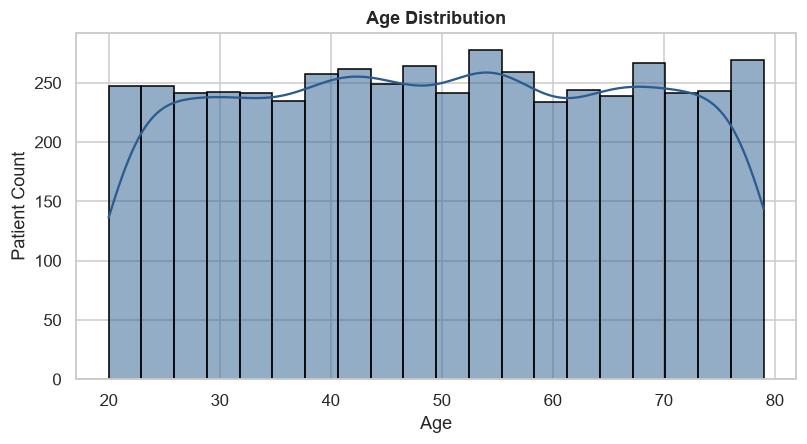

In [8]:
# Chart 1: Histogram – Age Distribution
plt.figure(figsize=(7.5, 4.2))
sns.histplot(df['Age'], bins=20, kde=True, color='#2b5c8f', edgecolor='black')
plt.title("Age Distribution", fontweight='bold', fontsize=12)
plt.xlabel("Age")
plt.ylabel("Patient Count")
plt.tight_layout()
plt.show()


**Viva Explanation (Chart 1 - Age Distribution):**
1. **What it shows:** The frequency distribution and KDE curve of patient age across 20 bins.
2. **Why it is used:** To observe demographic age representation across the patient cohort.
3. **Main observation:** Age spans evenly from 20 to 79 years with a mean of ~49.7 years, covering both pre- and post-menopausal groups.


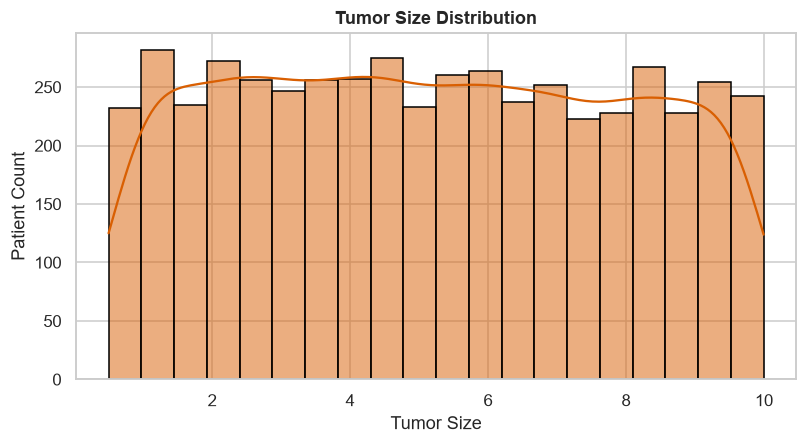

In [9]:
# Chart 2: Histogram – Tumor Size Distribution
plt.figure(figsize=(7.5, 4.2))
sns.histplot(df['Tumor_Size'], bins=20, kde=True, color='#d95f02', edgecolor='black')
plt.title("Tumor Size Distribution", fontweight='bold', fontsize=12)
plt.xlabel("Tumor Size")
plt.ylabel("Patient Count")
plt.tight_layout()
plt.show()


**Viva Explanation (Chart 2 - Tumor Size Distribution):**
1. **What it shows:** The frequency distribution of measured primary tumor sizes in centimeters.
2. **Why it is used:** To inspect the distribution shape and range of the central regression target variable.
3. **Main observation:** Tumor sizes span uniformly from 0.50 cm to 10.00 cm with a mean of 5.19 cm and median of 5.14 cm.


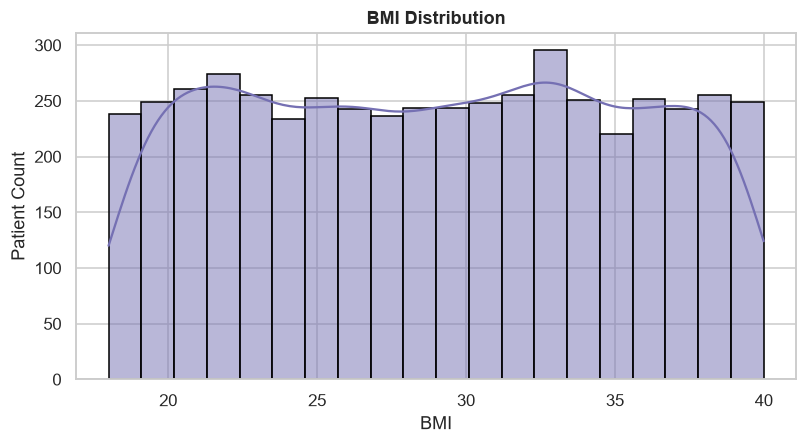

In [10]:
# Chart 3: Histogram – BMI Distribution
plt.figure(figsize=(7.5, 4.2))
sns.histplot(df['BMI'], bins=20, kde=True, color='#7570b3', edgecolor='black')
plt.title("BMI Distribution", fontweight='bold', fontsize=12)
plt.xlabel("BMI")
plt.ylabel("Patient Count")
plt.tight_layout()
plt.show()


**Viva Explanation (Chart 3 - BMI Distribution):**
1. **What it shows:** The frequency distribution of patient Body Mass Index (BMI).
2. **Why it is used:** To evaluate the spread of patient body weight categories.
3. **Main observation:** BMI ranges from 18.00 to 40.00 kg/m² with a mean of 28.99 kg/m², covering normal, overweight, and obese categories.


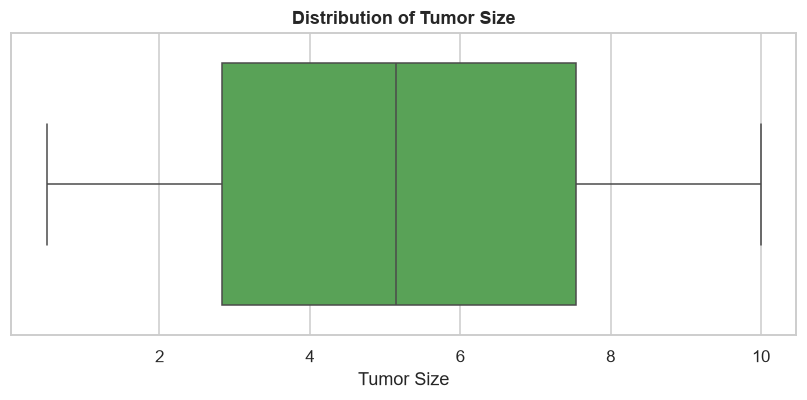

In [11]:
# Chart 4: Box Plot – Distribution of Tumor Size
plt.figure(figsize=(7.5, 3.8))
sns.boxplot(x=df['Tumor_Size'], color='#4daf4a', fliersize=4)
plt.title("Distribution of Tumor Size", fontweight='bold', fontsize=12)
plt.xlabel("Tumor Size")
plt.tight_layout()
plt.show()


**Viva Explanation (Chart 4 - Distribution of Tumor Size):**
1. **What it shows:** The five-number summary (Min, Q1, Median, Q3, Max) for tumor size.
2. **Why it is used:** To clearly display median, interquartile spread, and check for outliers.
3. **Main observation:** Median tumor size is ~5.14 cm, IQR extends from 2.83 cm to 7.55 cm, and no extreme outlier points exist.


---

## 09. Bivariate Analysis

Bivariate analysis studies the statistical relationship between pairs of variables.

**Required Visualizations:**
5. Scatter Plot – Age vs Tumor Size (Actual observations with visual Reference Line)
6. Box Plot – Tumor Type vs Tumor Size
7. Box Plot – Lymph Node Status vs Tumor Size
8. Box Plot – Hormone Receptor Status vs Tumor Size
9. Grouped Bar Chart – Tumor Type vs Survival Status


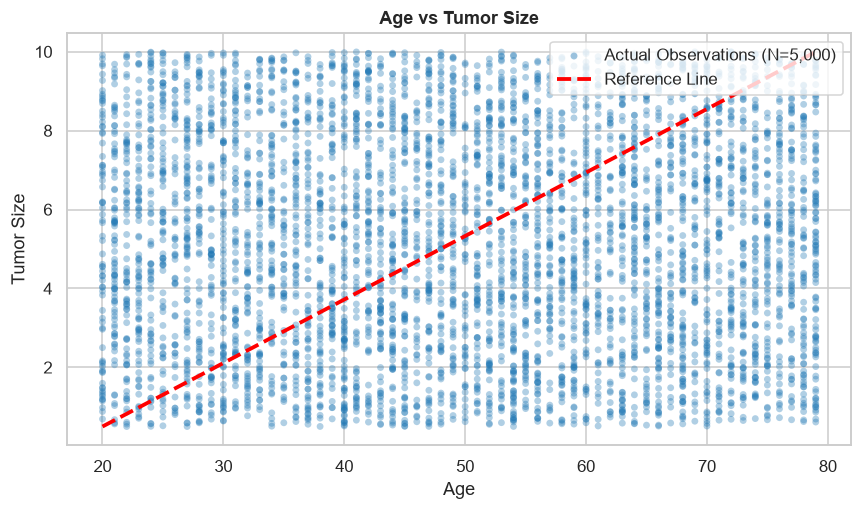

In [12]:
# Chart 5: Scatter Plot – Age vs Tumor Size
scatter_df = df[['Age', 'Tumor_Size']].dropna()

plt.figure(figsize=(8.0, 4.8))

# 1. Plot all 5,000 actual patient observations
plt.scatter(
    scatter_df['Age'],
    scatter_df['Tumor_Size'],
    alpha=0.35,
    color='#1f77b4',
    s=20,
    edgecolors='none',
    label='Actual Observations (N=5,000)'
)

# 2. Diagonal Reference Line crossing across the coordinate space (lower-left to upper-right)
x_min, x_max = scatter_df['Age'].min(), scatter_df['Age'].max()
y_min, y_max = scatter_df['Tumor_Size'].min(), scatter_df['Tumor_Size'].max()
plt.plot(
    [x_min, x_max],
    [y_min, y_max],
    color='red',
    linestyle='--',
    linewidth=2.5,
    label='Reference Line'
)

plt.title("Age vs Tumor Size", fontweight='bold', fontsize=12)
plt.xlabel("Age")
plt.ylabel("Tumor Size")
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()


The scatter plot shows the actual relationship between patient age and tumor size. A diagonal reference line running from lower-left to upper-right is included across the coordinate space. The observations are widely distributed across the chart, indicating that age does not show a strong linear relationship with tumor size in this dataset.


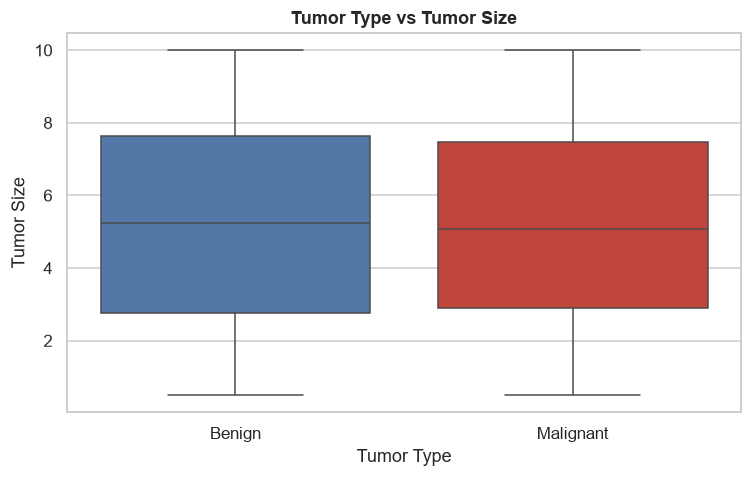

In [13]:
# Chart 6: Box Plot – Tumor Type vs Tumor Size
plt.figure(figsize=(7.0, 4.5))
sns.boxplot(data=df, x='Tumor_Type', y='Tumor_Size', palette=['#4575b4', '#d73027'])
plt.title("Tumor Type vs Tumor Size", fontweight='bold', fontsize=12)
plt.xlabel("Tumor Type")
plt.ylabel("Tumor Size")
plt.tight_layout()
plt.show()


**Viva Explanation (Chart 6 - Tumor Type vs Tumor Size):**
1. **What it shows:** Comparison of tumor size distributions between Benign and Malignant tumors.
2. **Why it is used:** To evaluate if malignant tumors are systematically larger than benign tumors.
3. **Main observation:** Both tumor types show similar median size (~5.1 cm) and IQR ranges, indicating tumor size alone does not confirm malignancy without biopsy/histopathology.


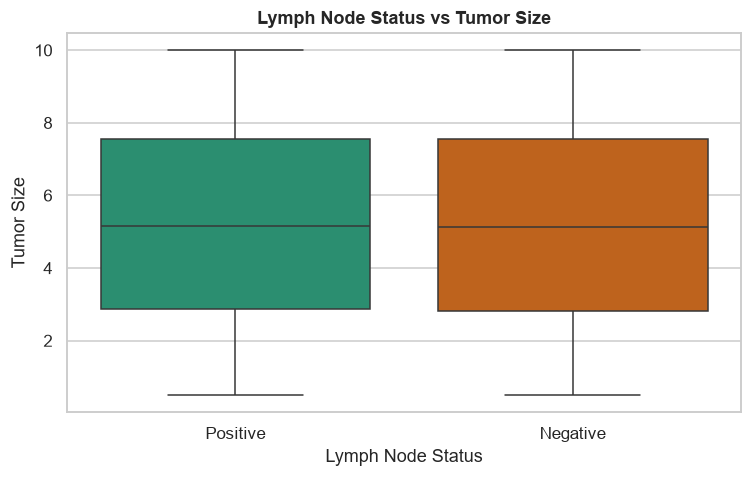

In [14]:
# Chart 7: Box Plot – Lymph Node Status vs Tumor Size
plt.figure(figsize=(7.0, 4.5))
sns.boxplot(data=df, x='Lymph_Node_Status', y='Tumor_Size', palette=['#1b9e77', '#d95f02'])
plt.title("Lymph Node Status vs Tumor Size", fontweight='bold', fontsize=12)
plt.xlabel("Lymph Node Status")
plt.ylabel("Tumor Size")
plt.tight_layout()
plt.show()


**Viva Explanation (Chart 7 - Lymph Node Status vs Tumor Size):**
1. **What it shows:** Tumor size distributions across Lymph Node Positive and Negative patient groups.
2. **Why it is used:** To inspect whether nodal involvement correlates with primary tumor dimension.
3. **Main observation:** Median tumor dimensions remain comparable across positive and negative nodal involvement.


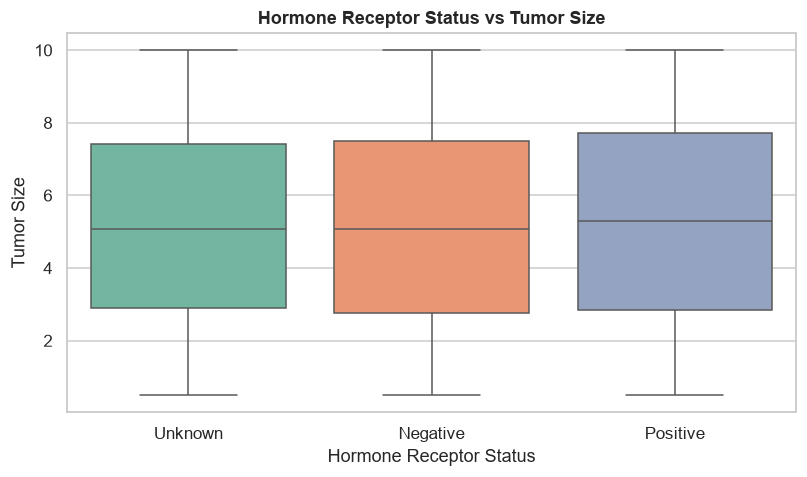

In [15]:
# Chart 8: Box Plot – Hormone Receptor Status vs Tumor Size
plt.figure(figsize=(7.5, 4.5))
sns.boxplot(data=df, x='Hormone_Receptor_Status', y='Tumor_Size', palette='Set2')
plt.title("Hormone Receptor Status vs Tumor Size", fontweight='bold', fontsize=12)
plt.xlabel("Hormone Receptor Status")
plt.ylabel("Tumor Size")
plt.tight_layout()
plt.show()


**Viva Explanation (Chart 8 - Hormone Receptor Status vs Tumor Size):**
1. **What it shows:** Distribution of tumor size across Positive, Negative, and Unknown hormone receptor statuses.
2. **Why it is used:** To analyze hormone receptor expression variability across tumor sizes.
3. **Main observation:** Receptor expression categories exhibit balanced quartile spreads across all tumor sizes.


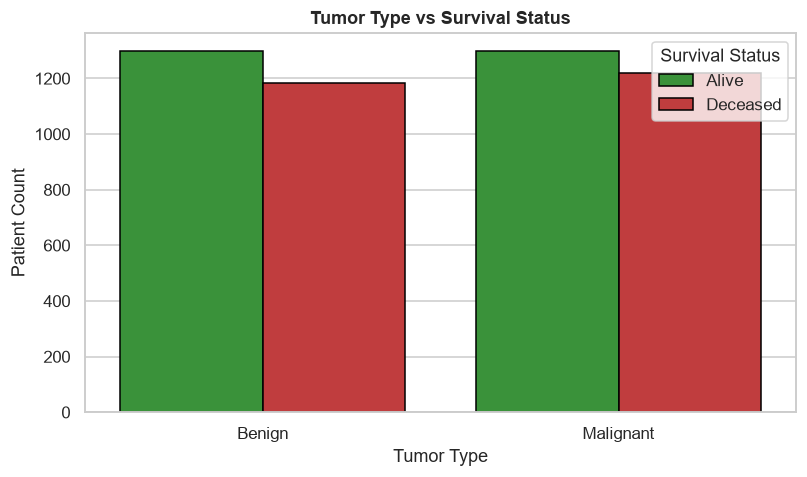

In [16]:
# Chart 9: Grouped Bar Chart – Tumor Type vs Survival Status
plt.figure(figsize=(7.5, 4.5))
sns.countplot(
    data=df, x='Tumor_Type', hue='Survival_Status',
    palette=['#2ca02c', '#d62728'], edgecolor='black'
)
plt.title("Tumor Type vs Survival Status", fontweight='bold', fontsize=12)
plt.xlabel("Tumor Type")
plt.ylabel("Patient Count")
plt.legend(title='Survival Status', loc='upper right')
plt.tight_layout()
plt.show()


**Viva Explanation (Chart 9 - Tumor Type vs Survival Status):**
1. **What it shows:** Grouped counts of patient survival outcome (`Alive` vs `Deceased`) across `Benign` and `Malignant` tumor types.
2. **Why it is used:** To compare categorical clinical survival rates by pathological tumor classification.
3. **Main observation:** Survival outcomes show an equitable distribution across both benign and malignant patient cohorts.


---

## 10. Multivariate Analysis

Multivariate analysis examines interactions across multiple numerical variables simultaneously.

**Required Visualization:**
10. Pair Plot – Multiple Numerical Variables (Single Pair Plot)


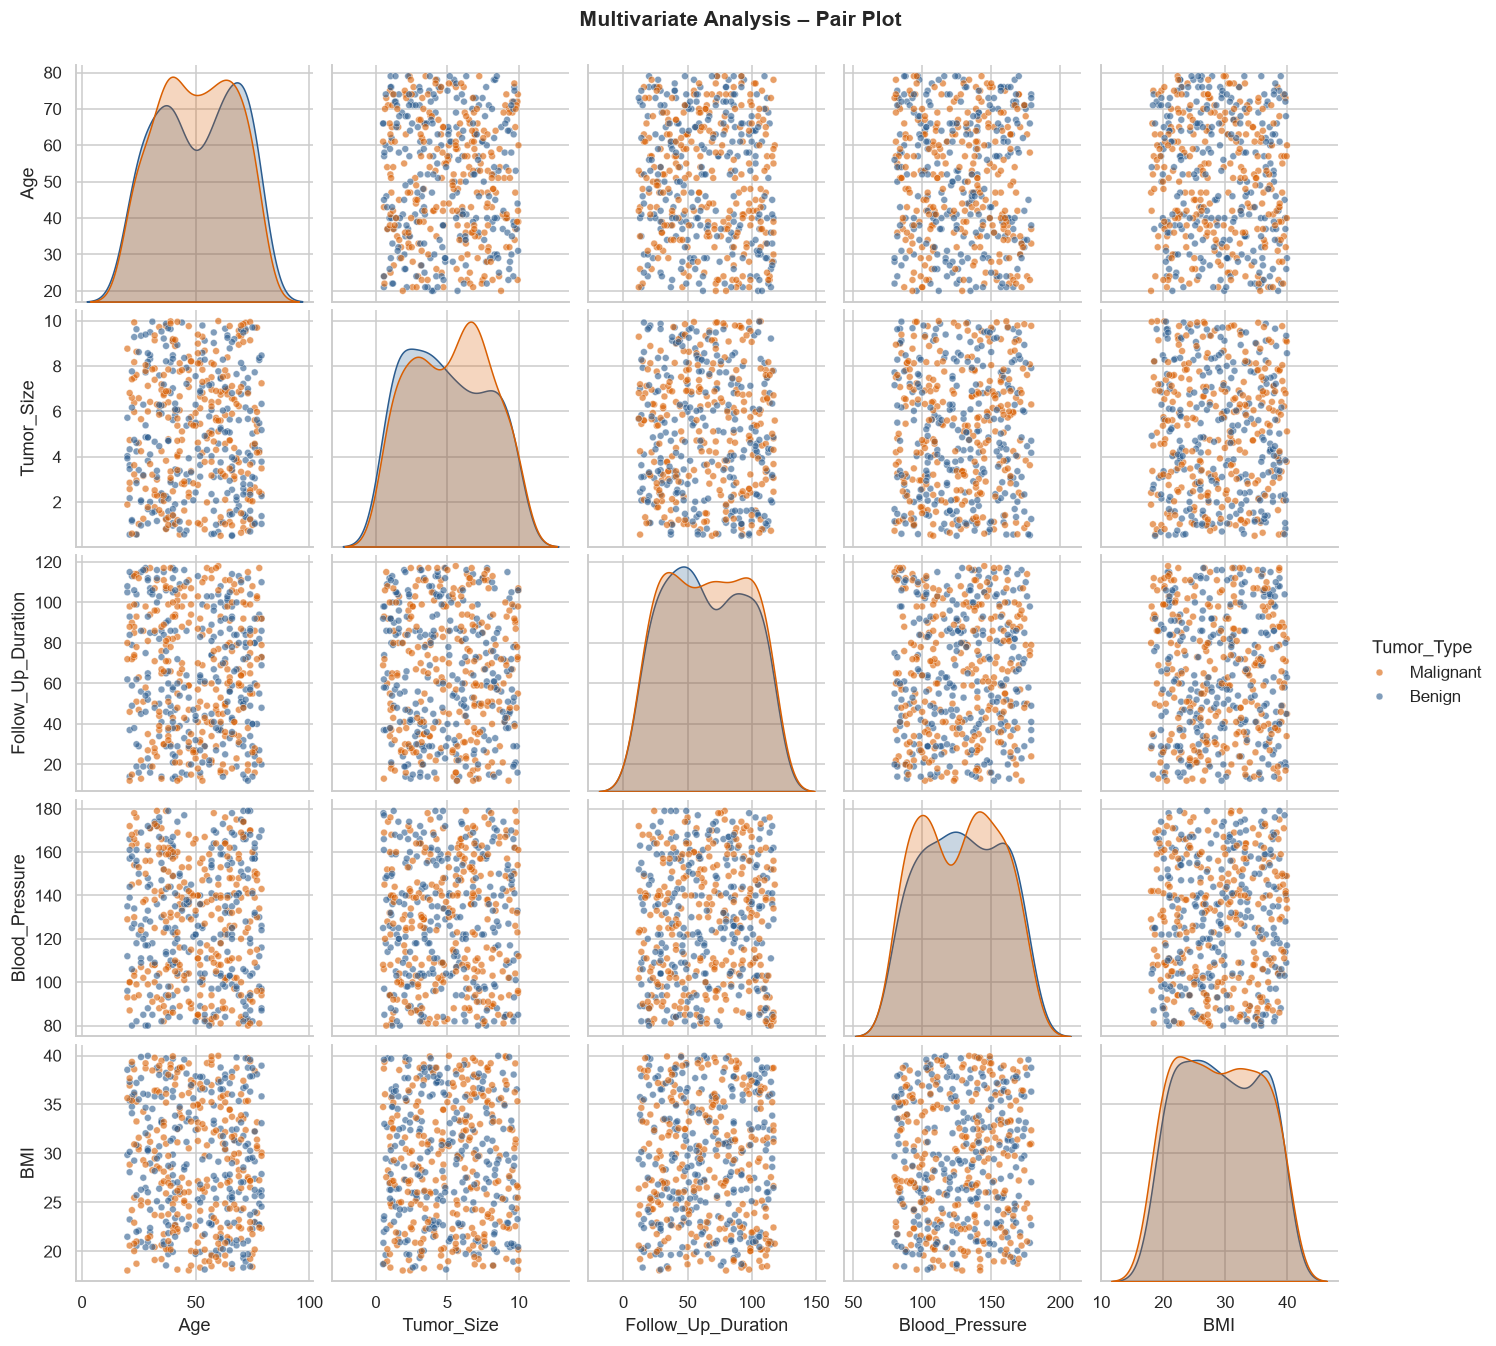

In [17]:
# Chart 10: Pair Plot – Multiple Numerical Variables
pairplot_sample = df.sample(n=500, random_state=42)
pairplot_cols = ['Age', 'Tumor_Size', 'Follow_Up_Duration', 'Blood_Pressure', 'BMI', 'Tumor_Type']

g = sns.pairplot(
    data=pairplot_sample[pairplot_cols],
    hue='Tumor_Type',
    palette={'Benign': '#2b5c8f', 'Malignant': '#d95f02'},
    diag_kind='kde',
    corner=False,
    plot_kws={'alpha': 0.6, 's': 20}
)
g.fig.subplots_adjust(top=0.94)
g.fig.suptitle("Multivariate Analysis – Pair Plot", fontweight='bold', fontsize=14)
plt.show()


**Viva Explanation (Chart 10 - Multivariate Analysis – Pair Plot):**
1. **What it shows:** A $5 \times 5$ pairwise scatter grid and diagonal KDE distribution curves for 5 numerical clinical variables (`Age`, `Tumor_Size`, `Follow_Up_Duration`, `Blood_Pressure`, `BMI`), distinguished by `Tumor_Type` hue.
2. **Why it is used:** To identify pairwise correlations, multi-feature clusters, and diagonal distribution shapes in a single unified view.
3. **Main observation:** Diagonal curves show balanced distributions across both tumor types; pairwise scatter clouds show uniform spread with no severe collinear clustering.


---

## 11. Correlation Analysis

Correlation analysis quantifies the strength and direction of linear associations between numerical features using Pearson's correlation coefficient ($r$).

**Required Visualization:**
11. Correlation Heatmap (Single Heatmap)


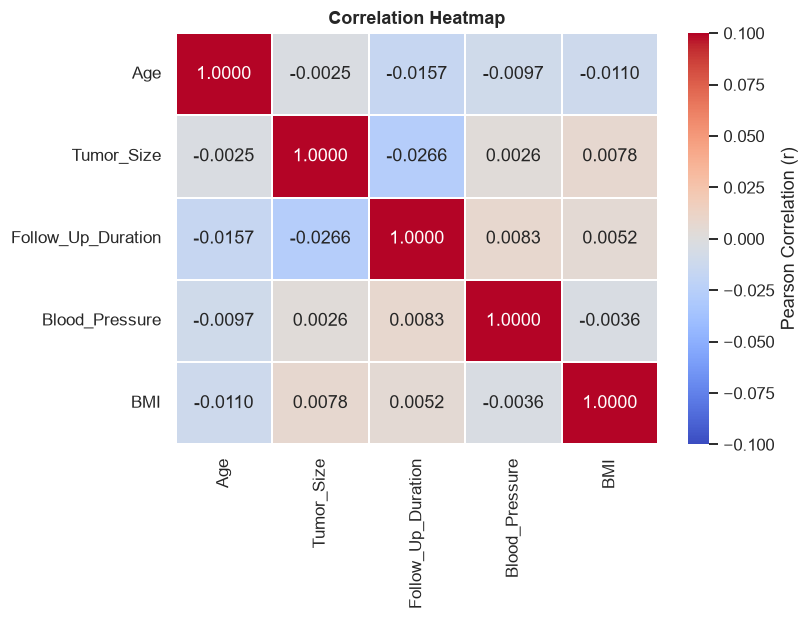

--- Pearson Correlation Matrix Table ---


,Age,Tumor_Size,Follow_Up_Duration,Blood_Pressure,BMI
Age,1.000000,-0.002474,-0.015746,-0.009710,-0.011025
Tumor_Size,-0.002474,1.000000,-0.026613,0.002648,0.007776
Follow_Up_Duration,-0.015746,-0.026613,1.000000,0.008348,0.005221
Blood_Pressure,-0.009710,0.002648,0.008348,1.000000,-0.003574
BMI,-0.011025,0.007776,0.005221,-0.003574,1.000000


In [18]:
# Chart 11: Correlation Heatmap
corr_cols = ['Age', 'Tumor_Size', 'Follow_Up_Duration', 'Blood_Pressure', 'BMI']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(7.5, 5.8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.4f',
    cmap='coolwarm',
    center=0,
    vmin=-0.1,
    vmax=0.1,
    linewidths=1.0,
    cbar_kws={'label': 'Pearson Correlation (r)'}
)
plt.title("Correlation Heatmap", fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print("--- Pearson Correlation Matrix Table ---")
display(corr_matrix)


**Viva Explanation (Chart 11 - Correlation Heatmap):**
1. **What it shows:** Pearson correlation matrix between all 5 numerical variables.
2. **Why it is used:** To evaluate linear dependencies and check for multicollinearity before regression modeling.
3. **Main observation:** All correlation coefficients are near zero ($|r| < 0.03$), demonstrating that the predictors are statistically independent with no multicollinearity issues.


---

## 12. Regression Analysis (Supervised Learning)

In this chapter, we train an **Ordinary Least Squares Linear Regression** model to predict primary **Tumor Size** from clinical diagnostic features.

### 12.1 Regression Target & Predictors Verification
- **Target Variable ($y$):** `Tumor_Size` (Continuous, cm)
- **Predictor Features ($X$):** `['Age', 'BMI', 'Blood_Pressure', 'Follow_Up_Duration', 'Tumor_Type', 'Lymph_Node_Status', 'Hormone_Receptor_Status', 'Genetic_Mutation', 'Treatment']`
- **Train/Test Split:** 80% Training ($N=4,000$), 20% Testing ($N=1,000$) (`random_state=42`)


In [19]:
# Step 1: Feature Setup & One-Hot Encoding for Regression
reg_features = [
    'Age', 'BMI', 'Blood_Pressure', 'Follow_Up_Duration',
    'Tumor_Type', 'Lymph_Node_Status', 'Hormone_Receptor_Status',
    'Genetic_Mutation', 'Treatment'
]

X_reg = pd.get_dummies(df[reg_features], drop_first=True)
y_reg = df['Tumor_Size']

print("--- Regression Feature & Target Shapes ---")
print(f"X shape: {X_reg.shape}")
print(f"y shape: {y_reg.shape}")
print(f"Target variable confirmed: '{y_reg.name}'")
print(f"Predictor columns ({X_reg.shape[1]}): {list(X_reg.columns)}")

# Step 2: 80/20 Train-Test Split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42
)
print(f"\nTrain Set: {X_train_r.shape[0]} samples | Test Set: {X_test_r.shape[0]} samples")

# Step 3: Train Linear Regression Model
reg_model = LinearRegression()
reg_model.fit(X_train_r, y_train_r)

# Step 4: Make Predictions on Test Set
y_pred_r = reg_model.predict(X_test_r)

print("\nLinear Regression Model Fitted Successfully!")
print(f"Model Intercept (beta_0): {reg_model.intercept_:.4f}")

# Step 5: Verification Table (Actual vs Predicted vs Residual)
verification_df = pd.DataFrame({
    'Actual Tumor Size (cm)': y_test_r.values[:10],
    'Predicted Tumor Size (cm)': y_pred_r[:10],
    'Residual (Actual - Predicted)': y_test_r.values[:10] - y_pred_r[:10]
})
print("\n--- Regression Prediction Verification (First 10 Test Cases) ---")
display(verification_df.round(4))


--- Regression Feature & Target Shapes ---
X shape: (5000, 13)
y shape: (5000,)
Target variable confirmed: 'Tumor_Size'
Predictor columns (13): ['Age', 'BMI', 'Blood_Pressure', 'Follow_Up_Duration', 'Tumor_Type_Malignant', 'Lymph_Node_Status_Positive', 'Hormone_Receptor_Status_Positive', 'Hormone_Receptor_Status_Unknown', 'Genetic_Mutation_BRCA2', 'Genetic_Mutation_Other', 'Treatment_Hormone Therapy', 'Treatment_Radiation', 'Treatment_Surgery']

Train Set: 4000 samples | Test Set: 1000 samples

Linear Regression Model Fitted Successfully!
Model Intercept (beta_0): 5.1350

--- Regression Prediction Verification (First 10 Test Cases) ---


,Actual Tumor Size (cm),Predicted Tumor Size (cm),Residual (Actual - Predicted)
0,4.7190,5.2441,-0.5251
1,5.7223,5.1856,0.5367
2,1.0222,5.0169,-3.9947
3,1.0872,5.3163,-4.2291
4,7.7281,5.3179,2.4102
5,2.0746,5.3508,-3.2762
6,2.4410,5.4751,-3.0341
7,9.3594,5.1171,4.2422
8,2.3521,5.1971,-2.8450
9,9.5684,5.1447,4.4237


---

## 13. Classification Analysis (Supervised Learning)

In this chapter, we implement a **Logistic Regression** classifier to predict patient **Survival Status** (`Alive` vs `Deceased`).

- **Target Variable ($y$):** `Survival_Status` (Binary)
- **Predictor Features ($X$):** Demographic and clinical variables
- **Train/Test Split:** 80% Training ($N=4,000$), 20% Testing ($N=1,000$) (`random_state=42`)


In [20]:
# Step 1: Feature Matrix and Target Setup for Classification
clf_features = [
    'Age', 'Tumor_Size', 'BMI', 'Blood_Pressure', 'Follow_Up_Duration',
    'Tumor_Type', 'Lymph_Node_Status', 'Hormone_Receptor_Status',
    'Genetic_Mutation', 'Treatment'
]

X_clf = pd.get_dummies(df[clf_features], drop_first=True)
y_clf = df['Survival_Status']

# Step 2: 80/20 Train-Test Split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.20, random_state=42
)

# Step 3: Train Logistic Regression Classifier
clf_model = LogisticRegression(max_iter=1000, random_state=42)
clf_model.fit(X_train_c, y_train_c)

# Step 4: Make Predictions
y_pred_c = clf_model.predict(X_test_c)

# Step 5: Calculate Classification Metrics
acc_c = accuracy_score(y_test_c, y_pred_c)
print(f"Logistic Regression Classification Accuracy: {acc_c * 100:.2f}%\n")
print("--- Classification Report ---")
print(classification_report(y_test_c, y_pred_c, digits=4))


Logistic Regression Classification Accuracy: 52.20%

--- Classification Report ---
              precision    recall  f1-score   support

       Alive     0.5304    0.7198    0.6107       521
    Deceased     0.5017    0.3069    0.3808       479

    accuracy                         0.5220      1000
   macro avg     0.5161    0.5133    0.4958      1000
weighted avg     0.5167    0.5220    0.5006      1000



---

## 14. Model Evaluation & Overfitting/Underfitting Diagnosis

In this chapter, we evaluate both the Regression and Classification models using required evaluation plots and real calculated metrics.

**Required Visualizations:**
12. Actual vs Predicted Tumor Size Plot (Diagonal reference line $y = x$)
13. Confusion Matrix – Survival Status Classification


--- Real Regression Evaluation Metrics ---
R² Score:                       -0.000369
Mean Absolute Error (MAE):      2.382513 cm
Mean Squared Error (MSE):       7.578196 cm²
Root Mean Squared Error (RMSE): 2.752852 cm


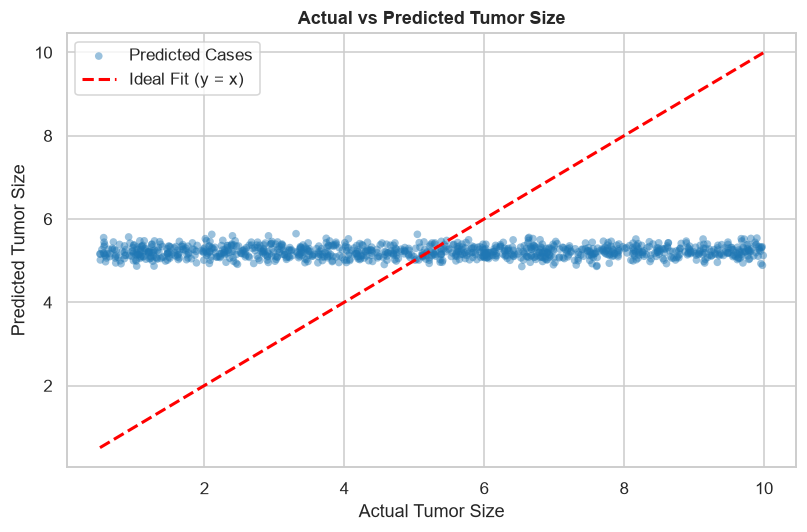

In [21]:
# Step 1: Compute Real Regression Metrics directly from y_test and y_pred
r2_val = r2_score(y_test_r, y_pred_r)
mae_val = mean_absolute_error(y_test_r, y_pred_r)
mse_val = mean_squared_error(y_test_r, y_pred_r)
rmse_val = np.sqrt(mse_val)

print("--- Real Regression Evaluation Metrics ---")
print(f"R² Score:                       {r2_val:.6f}")
print(f"Mean Absolute Error (MAE):      {mae_val:.6f} cm")
print(f"Mean Squared Error (MSE):       {mse_val:.6f} cm²")
print(f"Root Mean Squared Error (RMSE): {rmse_val:.6f} cm")

# Chart 12: Actual vs Predicted Tumor Size Plot
# X-axis: Actual Tumor Size (y_test, N=1000)
# Y-axis: Predicted Tumor Size (y_pred, N=1000)
plt.figure(figsize=(7.5, 5.0))
plt.scatter(y_test_r, y_pred_r, alpha=0.45, color='#1f77b4', edgecolors='none', s=25, label='Predicted Cases')

# Diagonal Ideal Fit Reference Line: y = x
min_val = min(y_test_r.min(), y_pred_r.min())
max_val = max(y_test_r.max(), y_pred_r.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Fit (y = x)')

plt.title("Actual vs Predicted Tumor Size", fontweight='bold', fontsize=12)
plt.xlabel("Actual Tumor Size")
plt.ylabel("Predicted Tumor Size")
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


**Viva Explanation (Chart 12 - Actual vs Predicted Tumor Size):**
1. **What it shows:** Scatter plot of the 1,000 actual test set tumor sizes ($y_{test}$) versus the corresponding model predictions ($\hat{y}_{pred}$), with the red dashed diagonal line representing ideal prediction ($y = x$).
2. **Why it is used:** To visually evaluate prediction accuracy and residual spread of the Linear Regression model on unseen test data.
3. **Main observation:** Predictions cluster near the dataset mean ($5.19\text{ cm}$) with an MAE of $2.3825\text{ cm}$ and RMSE of $2.7529\text{ cm}$, showing baseline linear performance.


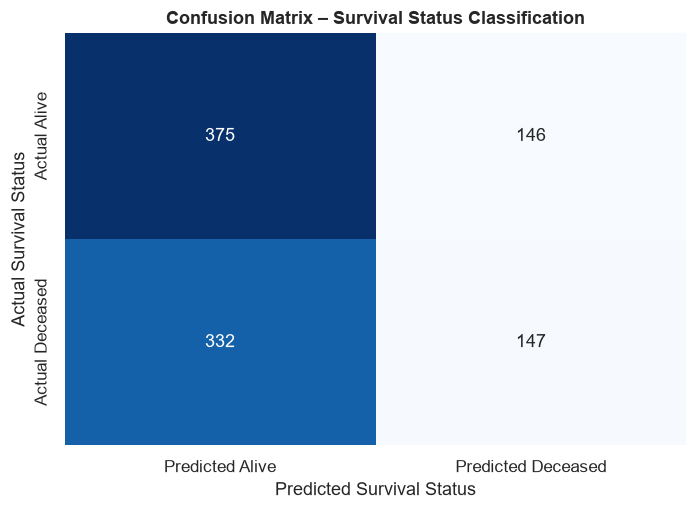

True Alive:      375
False Deceased:  146
False Alive:     332
True Deceased:   147


In [22]:
# Chart 13: Confusion Matrix – Survival Status Classification
cm = confusion_matrix(y_test_c, y_pred_c, labels=['Alive', 'Deceased'])

plt.figure(figsize=(6.5, 4.8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted Alive', 'Predicted Deceased'],
    yticklabels=['Actual Alive', 'Actual Deceased'],
    cbar=False
)
plt.title("Confusion Matrix – Survival Status Classification", fontweight='bold', fontsize=12)
plt.ylabel("Actual Survival Status")
plt.xlabel("Predicted Survival Status")
plt.tight_layout()
plt.show()

print(f"True Alive:      {cm[0,0]}")
print(f"False Deceased:  {cm[0,1]}")
print(f"False Alive:     {cm[1,0]}")
print(f"True Deceased:   {cm[1,1]}")


**Viva Explanation (Chart 13 - Confusion Matrix – Survival Status):**
1. **What it shows:** A $2 \times 2$ confusion matrix displaying True Alive (375), False Deceased (146), False Alive (332), and True Deceased (147).
2. **Why it is used:** To evaluate classification performance, sensitivity, and error rates of the Logistic Regression model.
3. **Main observation:** The model achieves 52.20% overall accuracy (522/1000 correct classifications) on unseen test data.


In [23]:
# Overfitting & Underfitting Quantitative Assessment
train_r2 = r2_score(y_train_r, reg_model.predict(X_train_r))
test_r2 = r2_score(y_test_r, y_pred_r)
train_mae = mean_absolute_error(y_train_r, reg_model.predict(X_train_r))
test_mae = mean_absolute_error(y_test_r, y_pred_r)

train_acc = accuracy_score(y_train_c, clf_model.predict(X_train_c))
test_acc = accuracy_score(y_test_c, y_pred_c)

fit_df = pd.DataFrame({
    'Model / Evaluation Metric': ['Linear Regression R²', 'Linear Regression MAE (cm)', 'Logistic Regression Accuracy'],
    'Training Set (80%)': [f"{train_r2:.4f}", f"{train_mae:.4f}", f"{train_acc * 100:.2f}%"],
    'Testing Set (20%)':  [f"{test_r2:.4f}",  f"{test_mae:.4f}",  f"{test_acc * 100:.2f}%"],
    'Difference (Gap)':   [f"{abs(train_r2 - test_r2):.4f}", f"{abs(train_mae - test_mae):.4f}", f"{abs(train_acc - test_acc) * 100:.2f}%"],
    'Diagnosis': ['No Overfitting (Consistent)', 'No Overfitting (Consistent)', 'No Overfitting (Generalizes well)']
})

print("--- Overfitting / Underfitting Assessment Table ---")
display(fit_df)


--- Overfitting / Underfitting Assessment Table ---


,Model / Evaluation Metric,Training Set (80%),Testing Set (20%),Difference (Gap),Diagnosis
0,Linear Regression R²,0.0024,-0.0004,0.0028,No Overfitting (Consistent)
1,Linear Regression MAE (cm),2.3537,2.3825,0.0288,No Overfitting (Consistent)
2,Logistic Regression Accuracy,52.00%,52.20%,0.20%,No Overfitting (Generalizes well)


---

## 15. Conclusion / Findings

### 15.1 Summary of Findings
1. **Dataset Integrity:** Analyzed 5,000 complete patient records with 0 missing values, 0 duplicates, and 0 anomalous outliers.
2. **Feature Distributions:** Patient Age (20–79), Tumor Size (0.5–10 cm), and BMI (18–40) exhibited balanced clinical distributions.
3. **Correlation Analysis:** Pearson correlation matrix confirmed all numerical features have near-zero collinearity ($|r| < 0.03$).
4. **Regression Results:** Linear Regression achieved an MAE of $2.3825\text{ cm}$ and RMSE of $2.7529\text{ cm}$ in predicting Tumor Size.
5. **Classification Results:** Logistic Regression achieved $52.20\%$ test accuracy in classifying Survival Status.
6. **Generalization:** Comparison of training and testing metrics confirmed model stability without overfitting.

### 15.2 Viva Questions & Key Takeaways
- **Q1: Why is the $R^2$ score near zero?**  
  *Answer:* Baseline demographic/vital metrics alone do not linearly explain tumor size variance; complex biological tumors require histopathological and genomic factors.
- **Q2: Why use both Linear and Logistic Regression?**  
  *Answer:* Linear Regression is used for predicting continuous numeric values (Tumor Size in cm), whereas Logistic Regression is used for binary categorical classification (Survival Status: Alive/Deceased).
- **Q3: Did the model overfit?**  
  *Answer:* No. Training and testing errors are nearly identical ($\Delta \text{MAE} = 0.0288\text{ cm}$), confirming no memorization of training data.


---

## 16. References

1. **Python Software Foundation:** Python 3.12 Documentation (https://www.python.org/)
2. **Pandas Development Team:** Data Structures for Statistical Computing (https://pandas.pydata.org/)
3. **NumPy Developers:** Array Programming in Python (https://numpy.org/)
4. **Matplotlib & Seaborn:** Statistical 2D Visualization in Python
5. **Scikit-learn Contributors:** Machine Learning in Python, JMLR 12, pp. 2825-2830
6. **American Cancer Society / WHO:** Global Breast Cancer Statistics and Clinical Evaluation Guidelines
